---
# TEIL B — Qualität (Meilenstein 4) → Ergebnis: *_qu

# 02 – Eniac Rabattstrategie: Datenqualität
**Meilenstein 4** (siehe Projektplan)

**Team-Entscheidung:** Status-Filter = nur `Completed` (einheitlich für die gesamte Qualitäts- und Analysephase).

**Inhaltsverzeichnis**
1. Import der bereinigten Datensätze (Meilenstein 1–3)
2. Arbeitskopien erstellen
3. Bereinigung der Zeichenketten (String-Spalten)
4. Fehlerhafte Preisangaben (products) korrigieren
5. Spalte `type` – fehlende Werte
6. Unerwünschte Bestellungen ausschließen
7. IDs zwischen orders und orderlines abgleichen
8. Bestellungen mit unbekannten Produkten ausschließen
9. Umsatz-Konsistenz prüfen (total_paid vs. unit_price_total)
10. Ausreißer entfernen (IQR-Regel)
11. Speichern

In [17]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

## 1. Import der bereinigten Datensätze aus Meilenstein 1–3

### 1.1 orderlines.csv

In [18]:
url = "https://drive.google.com/file/d/14L0kSSVCmwcpa3slDqTOYXwCSG6RHCE5/view?usp=sharing" # orderlines.csv
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)

### 1.2 orders.csv

In [19]:
url = "https://drive.google.com/file/d/1M8RQa0gGhLJjlYZxP80q65Uo6Hwfog2N/view?usp=sharing" # orders.csv
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)

### 1.3 products.csv

In [20]:
url = "https://drive.google.com/file/d/1wQllzqAYvzUVTUfcfJYsDjPKg_B5X3nt/view?usp=sharing" # products.csv
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

### 🔗 Brücke aus Teil A — eigene Arbeitskopie erstellen (kein Reimport von Drive)

In [21]:
orders_qu = orders_cl.copy()
orderlines_qu = orderlines_cl.copy()
products_qu = products_cl.copy()

## 2. Arbeitskopien erstellen

In [22]:
orderlines_qu = orderlines_qu.drop(columns=['product_id'])

**Ergebnis:** `product_id` enthielt ausschließlich den Wert 0 → entfernt.

*Hinweis:* Spaltennamen (`order_id` / `id_order`) werden NICHT umbenannt, um Konsistenz mit den bereits abgestimmten Merge-Aufrufen (`left_on`/`right_on`) zu wahren.

Datum konvertieren

In [23]:
orderlines_qu["unit_price"] = pd.to_numeric(orderlines_qu["unit_price"])

## 3. Bereinigung der Zeichenketten (String-Spalten)
Führende/nachgestellte Leerzeichen können bei Zusammenführung oder Vergleich zu Fehlern führen.

### 3.1 orders

In [24]:
str_cols = [col for col in orders_qu.columns if orders_qu[col].dtype == 'object']
for col in str_cols:
    orders_qu[col] = orders_qu[col].str.strip()

### 3.2 orderlines

In [25]:
str_cols = [col for col in orderlines_qu.columns if orderlines_qu[col].dtype == 'object']
for col in str_cols:
    orderlines_qu[col] = orderlines_qu[col].str.strip()

### 3.3 products

In [26]:
str_cols = [col for col in products_qu.columns if products_qu[col].dtype == 'object']
for col in str_cols:
    products_qu[col] = products_qu[col].str.strip()

## 4. Fehlerhafte Preisangaben (`products`) korrigieren
In Meilenstein 1–3 wurden Preise mit mehreren Dezimalpunkten (z. B. `34.56.546`) nur identifiziert, nicht korrigiert. Hier werden sie repariert statt gelöscht.

### 4.1 Fehlerhafte Preise identifizieren

In [27]:
price_mask = products_qu['price'].str.count(r'\.') > 1
products_qu.loc[price_mask, 'price'].shape[0]

377

### 4.2 Betroffene Bestellungen analysieren

In [28]:
sku_list = products_qu.loc[price_mask, 'sku']
orderlines_mask = orderlines_qu['sku'].isin(sku_list)
umsätze_zwei_punkte = orderlines_qu.loc[orderlines_mask, :]
umsätze_zwei_punkte.shape[0]

4150

### 4.3 Auswirkungen auf abgeschlossene Bestellungen

In [29]:
orders_umsätze_merged = orders_qu.merge(
    umsätze_zwei_punkte, left_on="order_id", right_on="id_order", how="inner"
)
orders_umsätze_merged['state'].value_counts()

,count
state,
Shopping Basket,2246
Completed,799
Place Order,601
Pending,258
Cancelled,246


**Ergebnis:** 799 der betroffenen Bestellungen haben Status `Completed` → **Entscheidung:** Preise korrigieren statt Zeilen löschen (Datenverlust vermeiden).

### 4.4 Preisformat korrigieren

In [30]:
products_qu.loc[price_mask, 'price'] = products_qu.loc[price_mask, 'price'].str.replace('.', '', 1)

**Ergebnis:** erste fehlerhafte Trennstelle (Tausenderpunkt) entfernt.

### 4.5 Datentyp umwandeln

In [31]:
products_qu['price'] = pd.to_numeric(products_qu['price'])

### 4.6 Preise an Euro-Format anpassen

In [32]:
price_mask = products_qu.price.astype(str).str.contains(r"\d+\.\d{3}")
products_qu.loc[price_mask, 'price'] = round(products_qu.loc[price_mask, 'price'], 2)

**Ergebnis:** `price` jetzt vollständig numerisch mit 2 Dezimalstellen.

## 5. Spalte `type` — fehlende Werte
50 fehlende Werte, überwiegend Apple-Produkte. Da keine zuverlässige Ableitung möglich ist, werden die Zeilen NICHT gelöscht, sondern mit `'unbekannt'` aufgefüllt.

### 5.1 Fehlende Werte identifizieren

In [33]:
type_mask = products_qu['type'].isna()
type_nan = products_qu.loc[type_mask, :]
type_nan.shape[0]

50

### 5.2 Auswirkungen auf Bestellungen analysieren

In [34]:
orderlines_type_merged = orderlines_qu.merge(type_nan, on='sku', how='inner')
orderlines_type_merged.shape[0]

184

In [35]:
dd = orders_qu.merge(orderlines_type_merged, left_on="order_id", right_on="id_order", how="inner")
mask = dd['state'] == 'Completed'
dd.loc[mask, :].shape[0]

13

### 5.3 Auffüllen mit `'unbekannt'`

In [36]:
products_qu.loc[type_mask, 'type'] = 'unbekannt'

**Ergebnis:** keine NaN-Werte mehr in `type`.

## 6. Unerwünschte Bestellungen ausschließen (nur `Completed`)

In [37]:
orders_qu = orders_qu.copy()
orderlines_qu = orderlines_qu.copy()
products_qu = products_qu.copy()

In [38]:
orders_qu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226904 entries, 0 to 226903
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      226904 non-null  int64  
 1   created_date  226904 non-null  object 
 2   total_paid    226904 non-null  float64
 3   state         226904 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.9+ MB


In [39]:
orders_qu.state.value_counts()

,count
state,
Shopping Basket,117809
Completed,46605
Place Order,40883
Pending,14374
Cancelled,7233


In [40]:
orders_qu = orders_qu.loc[orders_qu.state == "Completed", :]
orders_qu.shape

(46605, 4)

## 7. IDs zwischen orders und orderlines abgleichen

In [41]:
orders_qu.order_id.nunique()

46605

In [42]:
orderlines_qu.id_order.nunique()

204855

In [43]:
orders_orderlines = orders_qu.merge(
    orderlines_qu, how="inner", left_on="order_id", right_on="id_order"
)

In [44]:
# .unique() liefert die tatsächlichen IDs (nicht .nunique(), das nur die Anzahl liefert)
order_ids = orders_orderlines["order_id"].unique()

In [45]:
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(order_ids), :]
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(order_ids), :]

In [46]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(46560, 46560)

## 8. Bestellungen mit unbekannten Produkten ausschließen

In [47]:
orderlines_products = orderlines_qu.merge(
    products_qu, how="left", on="sku"
)[["id_order", "sku", "name"]]
orderlines_products.sample(10)

,id_order,sku,name
17477,372826,TWS0118,Twelve South BookBook Case Black iPhone 7 Plus
56678,506805,IFX0045,iFixit 64 Bit Driver Kit 64 parts Screwdriver
29871,414263,DOD0007,Gadget Dodow relaxation Shining White
46701,471324,APP2477,Apple iPhone 64GB Space Gray 8
19159,377206,OWC0191-4,Mac OWC 128GB memory (4x32GB) 1333MHz DIMM
21965,385727,OTT0141,Otterbox Clearly Protected gel iPhone Case SE ...
27150,404772,WAC0167,Wacom Intuos Creative Art Pen & Touch S Graphi...
14362,359667,SAN0156,SanDisk Ultra Fit Flash Drive 64GB USB 3.0
47144,472680,IFX0022,Battery Kit complete iFixit iPhone 5 battery c...
18729,375975,DLK0057,D-Link DCS-825L camera EyeOn Wi-Fi baby monitor


In [48]:
orderlines_products.name.isna().value_counts()

,count
name,
False,61710
True,393


In [49]:
orders_to_delete = orderlines_products.loc[orderlines_products.name.isna(), "id_order"].unique()
orders_to_delete

array([299638, 299706, 299712, 300029, 300251, 300340, 300558, 301178,
       301232, 301386, 301419, 301527, 301752, 301764, 301832, 301854,
       302069, 302078, 302431, 302447, 302872, 302890, 303158, 303274,
       303568, 304155, 304307, 304358, 304577, 304922, 305281, 305417,
       305824, 306293, 306419, 306743, 306907, 307102, 307969, 308132,
       308724, 309065, 309082, 309602, 309917, 310765, 311249, 311739,
       311982, 312031, 312445, 312565, 268659, 313073, 313726, 314221,
       314494, 314704, 314765, 315035, 315107, 315613, 316890, 317008,
       317178, 317360, 317552, 317803, 318378, 318928, 318935, 319101,
       319230, 320001, 315949, 320993, 321175, 321181, 322505, 322824,
       322865, 323457, 323573, 323669, 323741, 324014, 324310, 324652,
       325033, 325487, 325548, 326045, 326243, 326799, 326957, 326906,
       327268, 331604, 335991, 339946, 340890, 340892, 341352, 347004,
       348338, 348684, 348874, 348891, 348998, 349041, 349136, 349139,
      

In [50]:
orders_qu = orders_qu.loc[~orders_qu.order_id.isin(orders_to_delete), :]
orderlines_qu = orderlines_qu.loc[~orderlines_qu.id_order.isin(orders_to_delete), :]

In [51]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(46172, 46172)

## 9. Umsatz-Konsistenz prüfen (`total_paid` vs. `unit_price_total`)

In [52]:
orderlines_qu_copy = orderlines_qu.copy()
orders_qu_copy = orders_qu.copy()

In [53]:
orderlines_qu_copy["unit_price_total"] = (
    orderlines_qu_copy["product_quantity"] * orderlines_qu_copy["unit_price"]
)

In [54]:
orderlines_order_ids = orderlines_qu_copy.groupby("id_order", as_index=False)["unit_price_total"].sum()
# as_index=False: gruppierte Spalte bleibt als Spalte erhalten (nicht Index)

In [55]:
diff_df = orders_qu_copy.merge(
    orderlines_order_ids, left_on="order_id", right_on="id_order"
)

In [56]:
diff_df["difference"] = diff_df["total_paid"] - diff_df["unit_price_total"]
diff_df.head(10)

,order_id,created_date,total_paid,state,id_order,unit_price_total,difference
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16,6.99
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77,4.99
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99,6.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00,0.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98,6.99
5,246018,2017-02-13 23:02:57,211.95,Completed,246018,206.96,4.99
6,246405,2017-11-24 10:01:27,407.96,Completed,246405,275.75,132.21
7,247524,2018-01-09 14:21:34,167.98,Completed,247524,162.99,4.99
8,247643,2017-05-26 11:50:35,153.54,Completed,247643,153.54,0.00
9,250275,2017-11-19 22:34:54,54.99,Completed,250275,51.00,3.99


In [57]:
diff_df['difference'].round(2).value_counts()

,count
difference,
0.00,13818
4.99,11174
6.99,10801
3.99,6923
19.99,571
0.01,524
9.99,485
7.00,339
-0.01,252


In [58]:
diff_df.difference.mean().round(2)

np.float64(4.25)

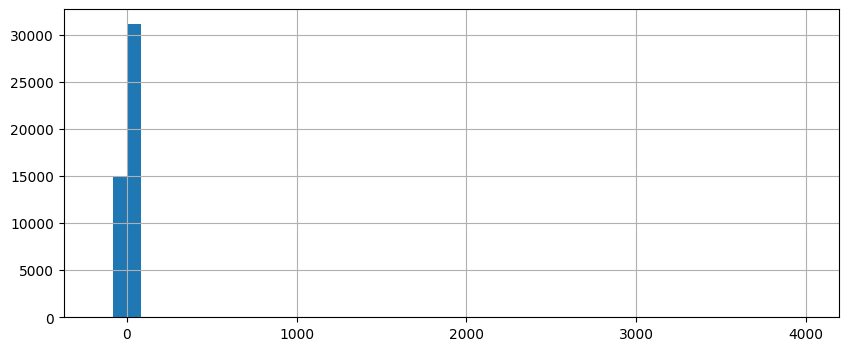

In [59]:
diff_df.difference.hist(bins=50, figsize=(10, 4));

In [60]:
diff_df.difference.describe()

,difference
count,46172.00
mean,4.25
std,24.83
min,-165.00
25%,0.00
50%,4.99
75%,6.99
max,3984.99


**Interpretation:** Quartile passen zu plausiblen Versandkosten (0,00 / 4,99 / 6,99). Extremwerte (Min/Max) deuten auf fehlerhafte Daten hin → Ausreißerbehandlung folgt.

## 10. Ausreißer entfernen (IQR-Regel)

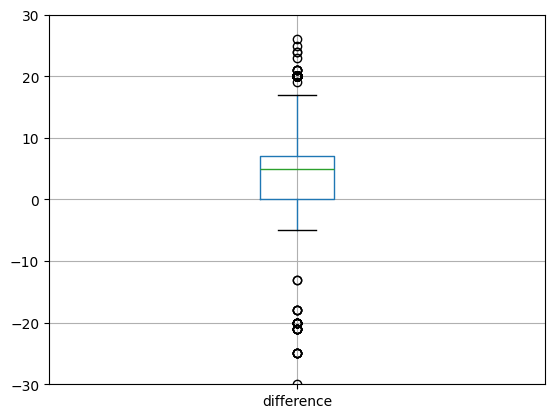

In [61]:
import matplotlib.pyplot as plt
ax = diff_df.boxplot("difference")
ax.set_ylim(-30, 30)
plt.show()

In [62]:
Q1 = diff_df["difference"].quantile(0.25)
Q3 = diff_df["difference"].quantile(0.75)
Q1, Q3

(np.float64(0.0), np.float64(6.989999999999981))

In [63]:
IQR = Q3 - Q1
IQR

np.float64(6.989999999999981)

In [64]:
Q1 - 1.5 * IQR  # untere Grenze

np.float64(-10.484999999999971)

In [65]:
Q3 + 1.5 * IQR  # obere Grenze

np.float64(17.47499999999995)

In [66]:
diff_no_outliers_df = diff_df.loc[
    (diff_df["difference"] >= (Q1 - 1.5 * IQR))
    & (diff_df["difference"] <= (Q3 + 1.5 * IQR)),
    :
]

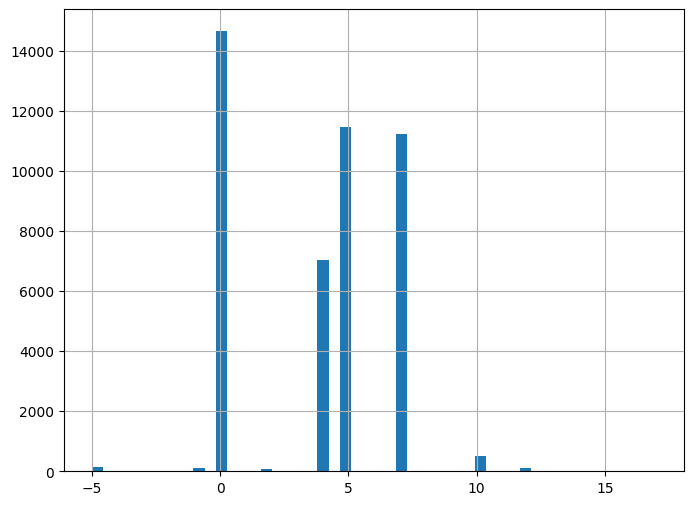

In [67]:
diff_no_outliers_df.difference.hist(bins=50, figsize=(8, 6));

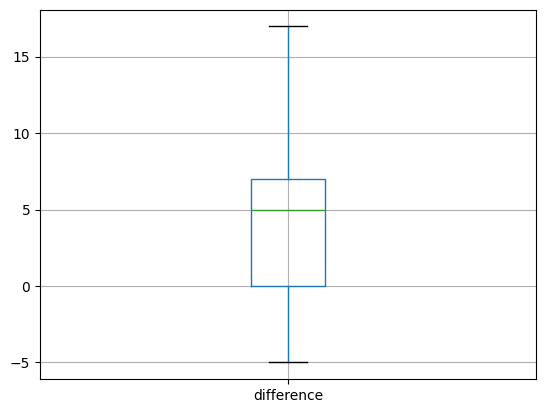

In [68]:
diff_no_outliers_df.boxplot("difference");

In [69]:
normal_diff_list = diff_no_outliers_df["order_id"]

In [70]:
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(normal_diff_list), :]
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(normal_diff_list), :]

In [71]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(45418, 45418)

## 11. Speichern (Abschluss Meilenstein 4)

- Export als `orders_qu.csv`, `orderlines_qu.csv`, `products_qu.csv`,`brands_qu.csv` → Ordner `2.Data/2.Data_cleaned_01/final_CSV_quality/`.

In [73]:
#Bereinigte Daten speichern in Drive

from google.colab import files

# orders_qu.to_csv("orders_qu.csv", index=False)
# files.download("orders_qu.csv")

# orderlines_qu.to_csv("orderlines_qu.csv", index=False)
# files.download("orderlines_qu.csv")

# products_qu.to_csv("products_qu.csv", index=False)
# files.download("products_qu.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>